# Phase 4 — Feature Engineering for Over-level and Delivery-level ML Tracks
This notebook constructs features at both over-level (Model A) and delivery-level (Model B) granularities, maps contextual ratings, adds hand-curated pitch types, and defines training targets.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, BASE_FEATURES, DELIVERY_FEATURES


## 1. Load Cleaned and Ratings Datasets
We load the clean ball-by-ball records, match metadata, and contextual ratings tables.


In [2]:
df_bbb = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'ball_by_ball.parquet'))
df_match_meta = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'match_meta.parquet'))
df_bat = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'batsman_ratings.parquet'))
df_bowl = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'bowler_ratings.parquet'))
df_venue = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'venue_ratings.parquet'))
print('All tables loaded successfully.')


All tables loaded successfully.


## 2. Hand-Curated Pitch Types Mapping
We define a hand-curated venue-to-pitch-type mapping based on common cricketing characteristics, and map all unspecified venues to 'balanced'.


In [3]:
venue_pitch_mapping = {
    'Wankhede Stadium': 'pace-friendly',
    'M.Chinnaswamy Stadium': 'pace-friendly',
    'Eden Gardens': 'balanced',
    'Feroz Shah Kotla': 'spin-friendly',
    'MA Chidambaram Stadium, Chepauk': 'spin-friendly',
    'Rajiv Gandhi International Stadium, Uppal': 'balanced',
    'Punjab Cricket Association Stadium, Mohali': 'pace-friendly',
    'Sawai Mansingh Stadium': 'balanced',
    'Dr DY Patil Sports Academy': 'balanced',
    'Brabourne Stadium': 'pace-friendly',
    'Maharashtra Cricket Association Stadium': 'balanced',
    'Sheikh Zayed Stadium': 'spin-friendly',
    'Dubai International Cricket Stadium': 'balanced',
    'Sharjah Cricket Stadium': 'spin-friendly',
    'Sardar Patel Stadium, Motera': 'spin-friendly',
    'Narendra Modi Stadium': 'balanced',
    'Arun Jaitley Stadium': 'spin-friendly',
    'Punjab Cricket Association Bindra Stadium, Mohali': 'pace-friendly',
    'Himachal Pradesh Cricket Association Stadium': 'pace-friendly',
    'JSCA International Stadium Complex': 'spin-friendly'
}
print(f'Mapped {len(venue_pitch_mapping)} top venues to custom pitch types.')


Mapped 20 top venues to custom pitch types.


## 3. Feature Assembly - Delivery-level features
We compute delivery-level indicators (streaks, rolling runs, spell economy, partnership stats, etc.) and merge contextual ratings.


In [4]:
df_bbb = df_bbb.sort_values(['match_id', 'innings_no', 'legal_balls_bowled'])

df_bbb['pitch_type'] = df_bbb['venue'].map(venue_pitch_mapping).fillna('balanced')

df_bbb['is_boundary'] = df_bbb['runs_batter'].isin([4, 6]).astype(int)
df_bbb['is_dot'] = (df_bbb['total_runs_this_ball'] == 0).astype(int)

print('Computing rolling streaks at ball granularity...')
df_bbb['runs_scored_last_5_balls'] = df_bbb.groupby(['match_id', 'innings_no'])['total_runs_this_ball'].rolling(5, min_periods=1).sum().reset_index(level=[0, 1], drop=True)
df_bbb['runs_scored_last_10_balls'] = df_bbb.groupby(['match_id', 'innings_no'])['total_runs_this_ball'].rolling(10, min_periods=1).sum().reset_index(level=[0, 1], drop=True)
df_bbb['wicket_fallen_last_10_balls'] = df_bbb.groupby(['match_id', 'innings_no'])['is_wicket'].rolling(10, min_periods=1).sum().reset_index(level=[0, 1], drop=True) > 0

boundary_dist = []
dot_streak = []
current_bound_dist = 0
current_dot_streak = 0
last_key = None

for idx, row in df_bbb.iterrows():
    key = (row['match_id'], row['innings_no'])
    if key != last_key:
        current_bound_dist = 0
        current_dot_streak = 0
        last_key = key
    
    if row['is_boundary']:
        current_bound_dist = 0
    else:
        current_bound_dist += 1
        
    if row['is_dot']:
        current_dot_streak += 1
    else:
        current_dot_streak = 0
        
    boundary_dist.append(current_bound_dist)
    dot_streak.append(current_dot_streak)

df_bbb['balls_since_last_boundary'] = boundary_dist
df_bbb['dot_ball_streak_current'] = dot_streak

df_bbb['bowler_cum_runs'] = df_bbb.groupby(['match_id', 'innings_no', 'bowler'])['total_runs_this_ball'].cumsum()
df_bbb['bowler_cum_legal_balls'] = df_bbb.groupby(['match_id', 'innings_no', 'bowler'])['extra_type'].transform(lambda x: (~x.isin(['wides', 'noballs'])).cumsum())
df_bbb['current_bowler_economy_this_spell'] = (df_bbb['bowler_cum_runs'] / (df_bbb['bowler_cum_legal_balls'] / 6.0)).fillna(8.2)

df_bbb['batsman_cum_runs'] = df_bbb.groupby(['match_id', 'innings_no', 'batsman'])['runs_batter'].cumsum()
df_bbb['batsman_cum_balls'] = df_bbb.groupby(['match_id', 'innings_no', 'batsman'])['extra_type'].transform(lambda x: (x != 'wides').cumsum())
df_bbb['current_batsman_strike_rate_this_innings'] = (df_bbb['batsman_cum_runs'] / df_bbb['batsman_cum_balls'] * 100.0).fillna(125.0)
df_bbb['current_batsman_balls_faced_this_innings'] = df_bbb['batsman_cum_balls']

df_bbb['partnership_id'] = df_bbb.groupby(['match_id', 'innings_no'])['is_wicket'].cumsum()
df_bbb['partnership_id_shifted'] = df_bbb.groupby(['match_id', 'innings_no'])['partnership_id'].shift(1).fillna(0).astype(int)
df_bbb['partnership_runs'] = df_bbb.groupby(['match_id', 'innings_no', 'partnership_id_shifted'])['total_runs_this_ball'].cumsum()
df_bbb['partnership_balls'] = df_bbb.groupby(['match_id', 'innings_no', 'partnership_id_shifted'])['extra_type'].transform(lambda x: (x != 'wides').cumsum())
print('Streaks computed.')


Computing rolling streaks at ball granularity...


Streaks computed.


In [5]:
print('Merging contextual ratings into ball-by-ball records...')
df_bbb = pd.merge(df_bbb, df_bat, on=['match_id', 'batsman'], how='left')
df_bbb = pd.merge(df_bbb, df_bowl, on=['match_id', 'bowler'], how='left')
df_bbb = pd.merge(df_bbb, df_venue, on=['match_id', 'venue'], how='left')

df_bbb = df_bbb.rename(columns={
    'career_average': 'batting_team_avg_batsman_rating',
    'career_economy': 'bowling_team_avg_bowler_rating'
})

df_bbb['batting_team_avg_batsman_rating'] = df_bbb['batting_team_avg_batsman_rating'].fillna(22.0)
df_bbb['bowling_team_avg_bowler_rating'] = df_bbb['bowling_team_avg_bowler_rating'].fillna(8.2)
df_bbb['venue_avg_first_innings_score'] = df_bbb['venue_avg_first_innings_score'].fillna(160.0)
df_bbb['venue_powerplay_run_rate'] = df_bbb['venue_powerplay_run_rate'].fillna(7.5)
df_bbb['venue_middle_run_rate'] = df_bbb['venue_middle_run_rate'].fillna(7.8)
df_bbb['venue_death_run_rate'] = df_bbb['venue_death_run_rate'].fillna(9.2)
df_bbb['venue_avg_wickets'] = df_bbb['venue_avg_wickets'].fillna(6.0)

df_bbb['venue_phase_run_rate'] = df_bbb['venue_middle_run_rate']
df_bbb.loc[df_bbb['over'] < 6, 'venue_phase_run_rate'] = df_bbb['venue_powerplay_run_rate']
df_bbb.loc[df_bbb['over'] >= 15, 'venue_phase_run_rate'] = df_bbb['venue_death_run_rate']

meta_merge = df_match_meta[['match_id', 'final_score_inn1', 'final_score_inn2', 'dls_revised_target']]
df_bbb = pd.merge(df_bbb, meta_merge, on='match_id', how='left')

df_bbb['final_score'] = df_bbb['final_score_inn1']
df_bbb.loc[df_bbb['innings_no'] == 2, 'final_score'] = df_bbb['final_score_inn2']

df_bbb['overs_completed'] = df_bbb['legal_balls_bowled'] / 6.0
df_bbb['overs_remaining'] = 20.0 - df_bbb['overs_completed']
df_bbb['wickets_lost'] = df_bbb['cumulative_wickets']
df_bbb['wickets_in_hand'] = 10 - df_bbb['wickets_lost']
df_bbb['current_score'] = df_bbb['cumulative_score']

df_bbb['run_rate_so_far'] = (df_bbb['current_score'] / df_bbb['overs_completed']).replace([np.inf, -np.inf], 8.0).fillna(8.0)

df_bbb['required_run_rate'] = np.nan
df_bbb.loc[df_bbb['innings_no'] == 2, 'required_run_rate'] = ((df_bbb['final_score_inn1'] + 1 - df_bbb['current_score']) / df_bbb['overs_remaining']).replace([np.inf, -np.inf], np.nan)

df_bbb['powerplay_flag'] = (df_bbb['over'] < 6).astype(int)
df_bbb['death_overs_flag'] = (df_bbb['over'] >= 15).astype(int)

df_bbb['runs_remaining_target'] = df_bbb['final_score'] - df_bbb['current_score']
df_bbb['normalized_resource_target'] = df_bbb['final_score'] / df_bbb['venue_avg_first_innings_score']

df_bbb = pd.get_dummies(df_bbb, columns=['pitch_type'], prefix='pitch_type')
for col in ['pitch_type_ pace-friendly', 'pitch_type_ spin-friendly', 'pitch_type_ balanced']:
    if col not in df_bbb.columns:
        df_bbb[col] = 0

df_bbb = df_bbb.replace([np.inf, -np.inf], np.nan)
df_bbb.to_parquet(os.path.join(PROCESSED_DATA_DIR, 'delivery_features.parquet'), index=False)
print(f'Saved delivery features: {len(df_bbb)} rows.')


Merging contextual ratings into ball-by-ball records...


Saved delivery features: 1090092 rows.


In [6]:
df_overs_feat = df_bbb.groupby(['match_id', 'innings_no', 'over']).last().reset_index()
df_overs_feat.to_parquet(os.path.join(PROCESSED_DATA_DIR, 'over_features.parquet'), index=False)
print(f'Saved over-level features: {len(df_overs_feat)} rows.')


Saved over-level features: 175658 rows.


## 4. Visualizations & Correlation analysis


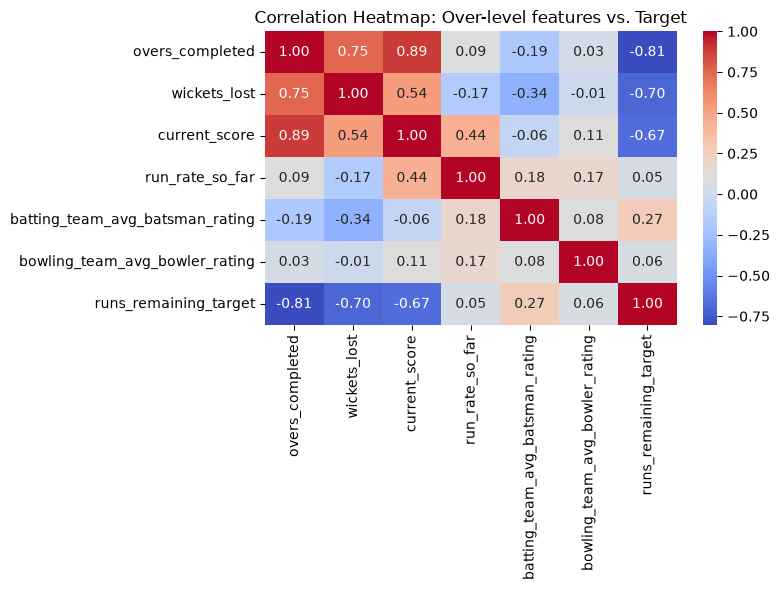

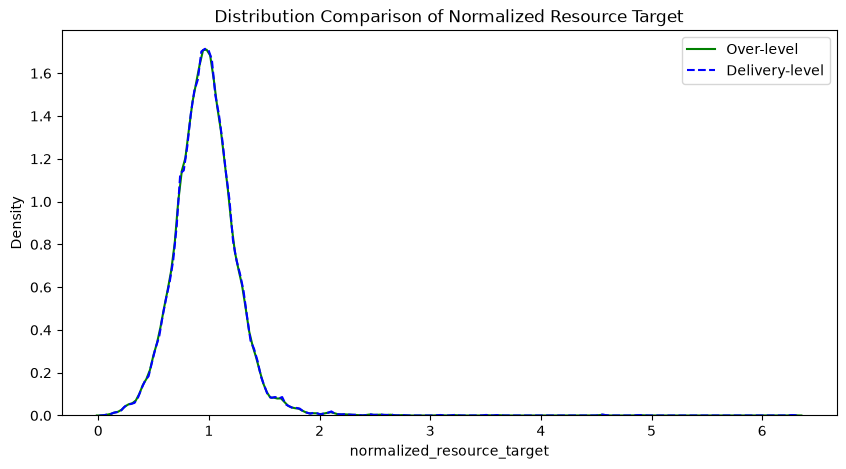

In [7]:
num_cols = ['overs_completed', 'wickets_lost', 'current_score', 'run_rate_so_far', 
            'batting_team_avg_batsman_rating', 'bowling_team_avg_bowler_rating', 'runs_remaining_target']
corr_matrix = df_overs_feat[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Over-level features vs. Target')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'features_correlation_heatmap.png'))
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(df_overs_feat['normalized_resource_target'], label='Over-level', color='green')
sns.kdeplot(df_bbb['normalized_resource_target'], label='Delivery-level', color='blue', linestyle='--')
plt.title('Distribution Comparison of Normalized Resource Target')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'target_distributions_comparison.png'))
plt.show()


## Summary & Conclusion
Both over-level and delivery-level feature tables have been generated with targets and ratings merged.
